In [ ]:
#Next approach

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [7]:

# Load the actual data file
df = pd.read_csv("TEST IT_ZENITHE.csv")

# Clean column names if needed
df.columns = [col.strip() for col in df.columns]

print("Dataset Overview:")
print(f"Shape: {df.shape}")
display(df.head())


Dataset Overview:
Shape: (387, 17)


,i,t,Années,Countries,MPI,informality,Dev fin,Income group,RN AI 10% les +,RN AI 1% les +,RN AI 50% les -,Control of Corruption,Government Effectiveness,Croiss Pop,Urbanisation,Log GDP,EDUC
0,1,1,"2,010",Benin,0.412,0.517733,0.158348,Lower-middle income,0.5090,0.1526,0.1315,0.295,0.325,0.028060,0.43093,2.967663,0.474146
1,1,2,"2,011",Benin,0.412,0.514761,0.165743,Lower-middle income,0.5131,0.1515,0.1288,0.332,0.355,0.028038,0.43608,2.967415,0.474146
2,1,3,"2,012",Benin,0.412,0.512169,0.156476,Lower-middle income,0.5216,0.1574,0.1253,0.204,0.370,0.027977,0.44125,2.974935,0.507508
3,1,4,"2,013",Benin,0.412,0.503966,0.164539,Lower-middle income,0.5301,0.1633,0.1217,0.246,0.365,0.027907,0.44642,2.992288,0.540871
4,1,5,"2,014",Benin,0.412,0.494458,0.167371,Lower-middle income,0.5387,0.1692,0.1182,0.298,0.356,0.027821,0.45166,3.006223,0.547326


In [9]:
print(df.columns)

Index(['i', 't', 'Années', 'Countries', 'MPI', 'informality', 'Dev fin',
       'Income group', 'RN AI 10% les +', 'RN AI 1% les +', 'RN AI 50% les -',
       'Control of Corruption', 'Government Effectiveness', 'Croiss Pop',
       'Urbanisation', 'Log GDP', 'EDUC'],
      dtype='object')


In [11]:
# Check for missing values
print("\nMissing values:")
display(df.isnull().sum())

# Basic statistical summary
print("\nStatistical Summary:")
display(df.describe())


Missing values:


i                            0
t                            0
Années                       0
Countries                    0
MPI                          0
informality                 27
Dev fin                     27
Income group                 0
RN AI 10% les +              9
RN AI 1% les +               9
RN AI 50% les -             10
Control of Corruption       36
Government Effectiveness    36
Croiss Pop                   0
Urbanisation                 0
Log GDP                      3
EDUC                         0
dtype: int64


Statistical Summary:


,i,t,MPI,Dev fin,RN AI 10% les +,RN AI 1% les +,RN AI 50% les -,Control of Corruption,Government Effectiveness,Croiss Pop,Urbanisation,Log GDP,EDUC
count,387.000000,387.000000,387.000000,360.000000,378.000000,378.000000,377.000000,351.000000,351.000000,387.000000,387.000000,384.000000,387.000000
mean,22.000000,5.000000,0.315371,0.219496,0.493247,0.157972,0.140541,0.278598,0.242670,0.024944,0.416574,3.042405,0.344324
std,12.425738,2.585331,0.157102,0.224665,0.057991,0.038662,0.029110,0.190315,0.166738,0.007051,0.170984,0.328807,0.257152
min,1.000000,1.000000,0.004000,0.000030,0.372200,0.085500,0.062500,0.000000,0.000000,0.002596,0.106420,2.424346,0.000000
25%,11.000000,3.000000,0.182000,0.110734,0.451425,0.133000,0.122600,0.121000,0.098000,0.022328,0.287635,2.801626,0.131155
50%,22.000000,5.000000,0.324000,0.155491,0.488900,0.150550,0.141300,0.261000,0.219000,0.026608,0.411620,3.003191,0.370114
75%,33.000000,7.000000,0.439000,0.222558,0.518300,0.173700,0.166200,0.400000,0.353000,0.029211,0.505205,3.187797,0.489750
max,43.000000,9.000000,0.642000,1.288384,0.681300,0.310600,0.211300,0.755000,0.657000,0.039073,0.893700,3.848012,1.116274


In [15]:
# Handle missing values
print("\nHandling missing values...")

# First, check data types and convert string columns to numeric where appropriate
print("\nChecking data types and converting to numeric...")
for col in df.columns:
    if df[col].dtype == 'object' and col not in ['Countries', 'Income group']:
        # Try to convert to numeric, coerce errors to NaN
        df[col] = pd.to_numeric(df[col], errors='coerce')
        print(f"  Converted {col} to numeric")

# Now handle missing values for numerical columns
numerical_cols_with_na = ['informality', 'Dev fin', 'RN AI 10% les +', 'RN AI 1% les +', 
                          'RN AI 50% les -', 'Control of Corruption', 'Government Effectiveness', 'Log GDP']

for col in numerical_cols_with_na:
    if col in df.columns:
        # Use simple median imputation
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"  Imputed {col} missing values with median: {median_val}")

# Check if all missing values are handled
print("\nRemaining missing values after imputation:")
display(df.isnull().sum())


Handling missing values...

Checking data types and converting to numeric...
  Converted Années to numeric
  Converted informality to numeric
  Imputed informality missing values with median: 0.395021
  Imputed Dev fin missing values with median: 0.155491299
  Imputed RN AI 10% les + missing values with median: 0.4889
  Imputed RN AI 1% les + missing values with median: 0.15055000000000002
  Imputed RN AI 50% les - missing values with median: 0.1413
  Imputed Control of Corruption missing values with median: 0.261
  Imputed Government Effectiveness missing values with median: 0.219
  Imputed Log GDP missing values with median: 3.003191331

Remaining missing values after imputation:


i                             0
t                             0
Années                      387
Countries                     0
MPI                           0
informality                   0
Dev fin                       0
Income group                  0
RN AI 10% les +               0
RN AI 1% les +                0
RN AI 50% les -               0
Control of Corruption         0
Government Effectiveness      0
Croiss Pop                    0
Urbanisation                  0
Log GDP                       0
EDUC                          0
dtype: int64


Feature Distributions:


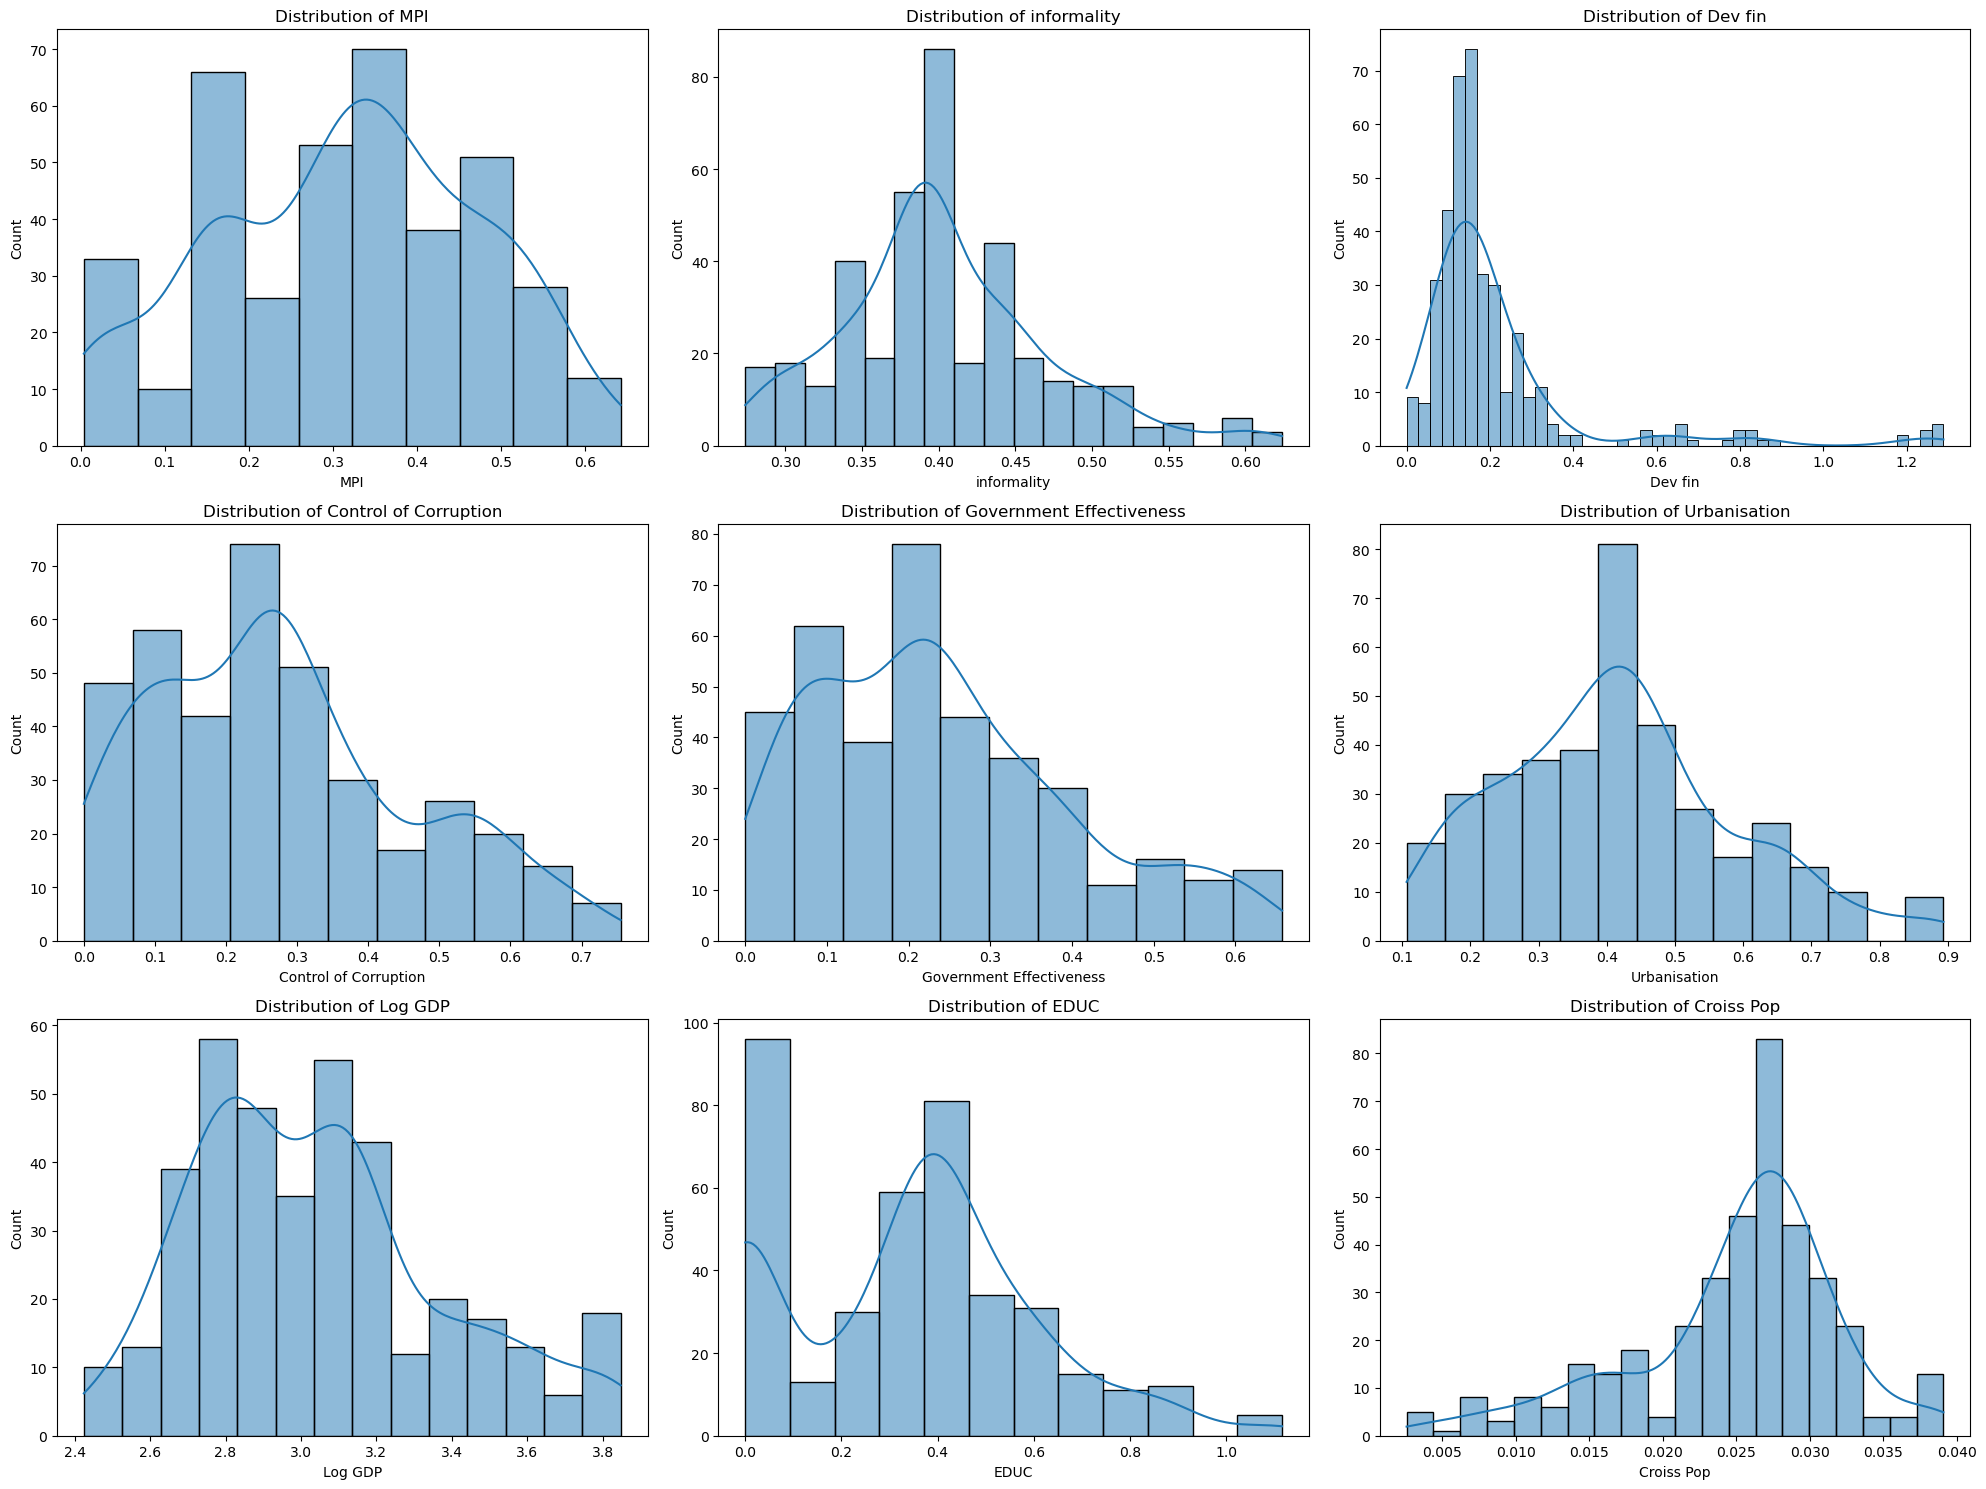

In [17]:
# Feature distributions
print("\nFeature Distributions:")
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
axes = axes.flatten()

# Adjust the column names to match your actual data
numerical_features = ['MPI', 'informality', 'Dev fin', 
                      'Control of Corruption', 'Government Effectiveness', 
                      'Urbanisation', 'Log GDP', 'EDUC', 'Croiss Pop']

for i, feature in enumerate(numerical_features):
    if i < len(axes):
        sns.histplot(df[feature], kde=True, ax=axes[i])
        axes[i].set_title(f'Distribution of {feature}')
        axes[i].set_xlabel(feature)
plt.tight_layout()
plt.show()


Correlation with Poverty Rate (MPI):


MPI                         1.000000
Croiss Pop                  0.540123
RN AI 50% les -             0.369078
informality                 0.160141
t                          -0.134275
EDUC                       -0.152922
i                          -0.174349
RN AI 1% les +             -0.254511
Control of Corruption      -0.321797
RN AI 10% les +            -0.336101
Government Effectiveness   -0.421475
Dev fin                    -0.519503
Urbanisation               -0.593399
Log GDP                    -0.798717
Années                           NaN
Name: MPI, dtype: float64

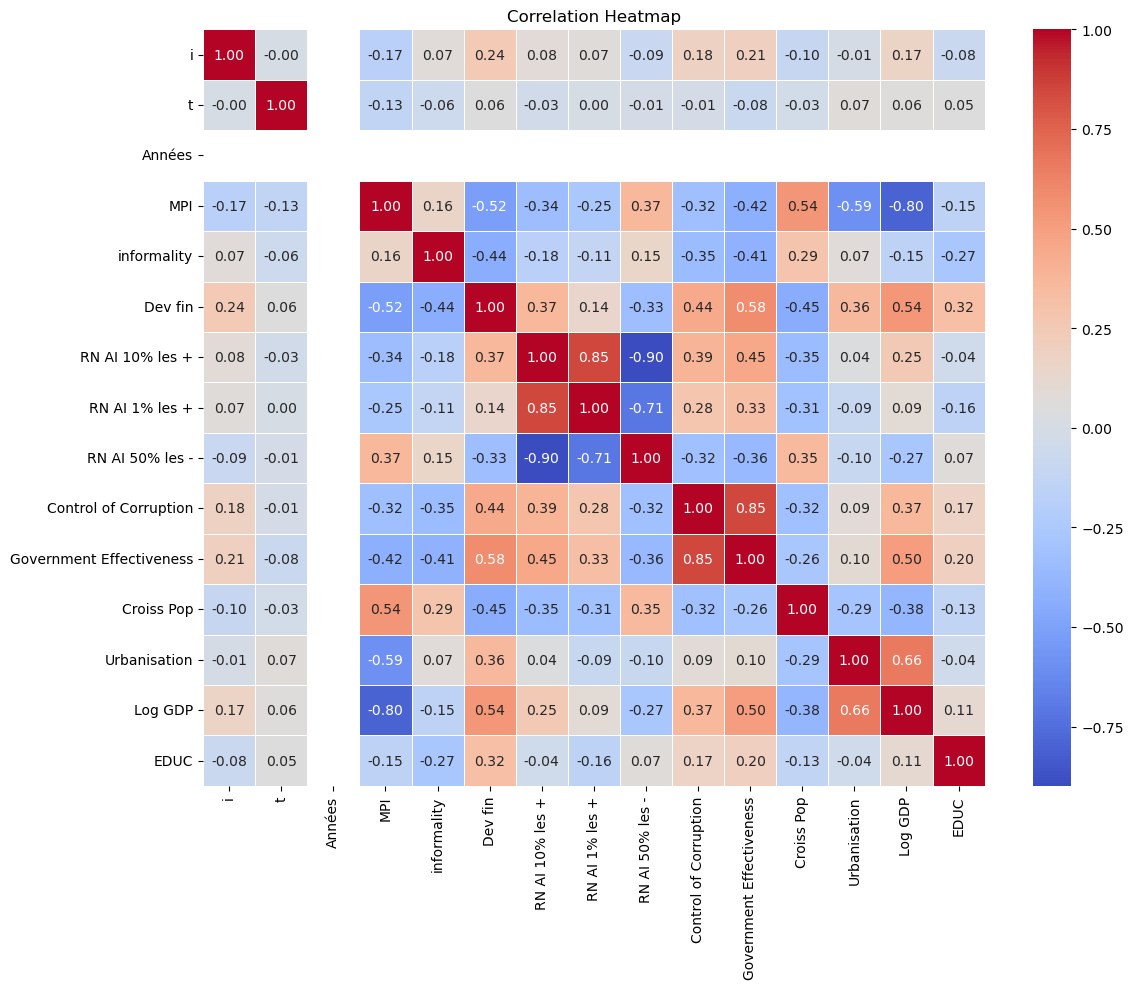

In [19]:
# Correlation Analysis
print("\nCorrelation with Poverty Rate (MPI):")
correlations = df.select_dtypes(include=[np.number]).corr()['MPI'].sort_values(ascending=False)
display(correlations)

# Correlation Heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


Poverty Rate by Country (Average):


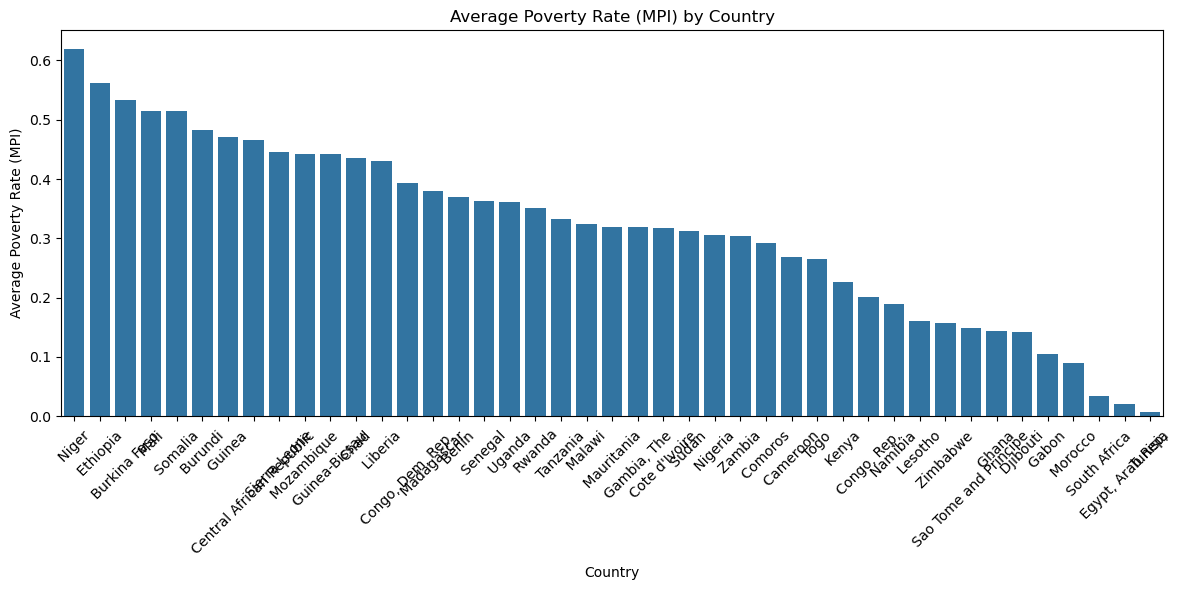

In [23]:
# Heatmap by Country
print("\nPoverty Rate by Country (Average):")
poverty_by_country = df.groupby('Countries')['MPI'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=poverty_by_country.index, y=poverty_by_country.values)
plt.title('Average Poverty Rate (MPI) by Country')
plt.xlabel('Country')
plt.ylabel('Average Poverty Rate (MPI)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
# Heatmap of Poverty Rate by Country and Year
print("\nPoverty Rate Heatmap by Country and Year:")
pivot_df = df.pivot_table(index='Countries', columns='Années', values='MPI', aggfunc='mean')
plt.figure(figsize=(14, 8))
sns.heatmap(pivot_df, cmap='YlOrRd', annot=True, fmt='.1f')
plt.title('Poverty Rate by Country and Year')
plt.xlabel('Year')
plt.ylabel('Country')
plt.tight_layout()
plt.show()


Poverty Rate Heatmap by Country and Year:


ValueError: zero-size array to reduction operation fmin which has no identity

<Figure size 1400x800 with 0 Axes>


Poverty Rate Heatmap by Country and Year:
Number of unique countries: 43
Number of unique years: 0

Creating heatmap with top 10 countries by data availability


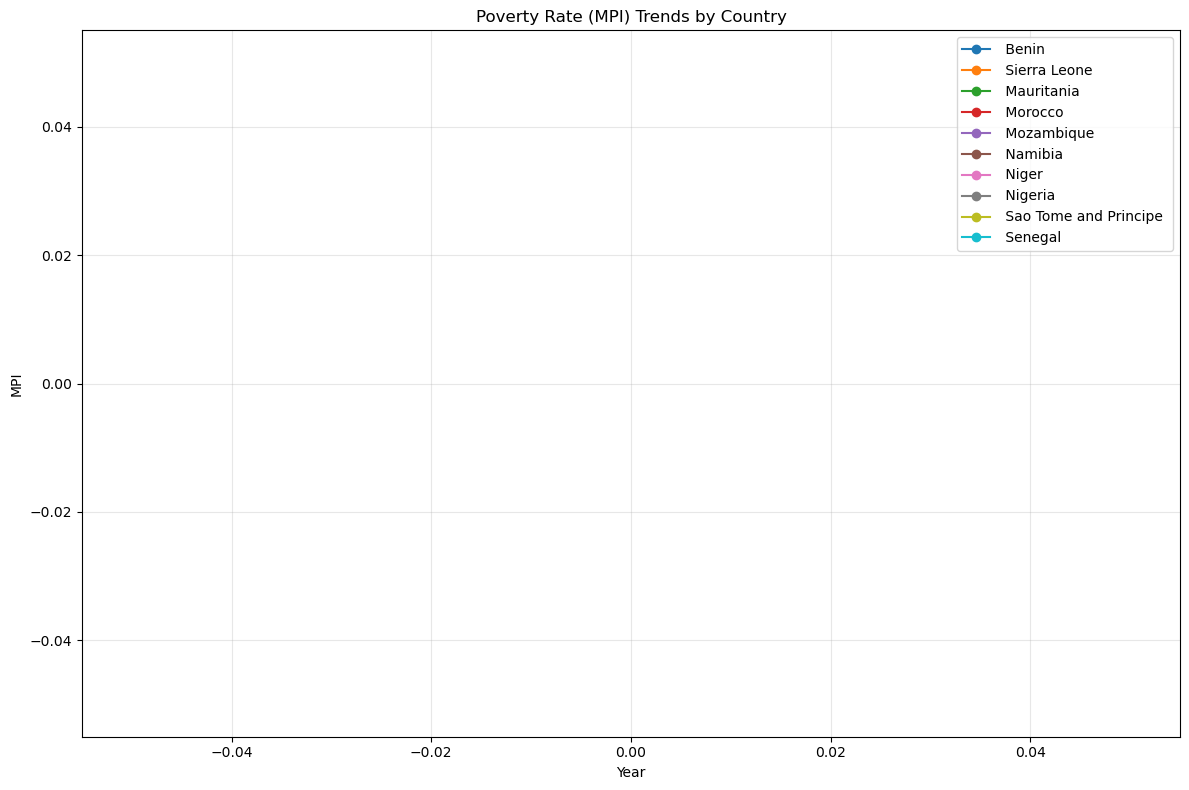

ValueError: zero-size array to reduction operation fmin which has no identity

<Figure size 1400x800 with 0 Axes>

In [29]:
# Heatmap of Poverty Rate by Country and Year
print("\nPoverty Rate Heatmap by Country and Year:")
# Check how many unique values we have
print(f"Number of unique countries: {df['Countries'].nunique()}")
print(f"Number of unique years: {df['Années'].nunique()}")

# If we have too many unique combinations, we'll need to filter
# Let's select top countries by data availability 
country_data_counts = df.groupby('Countries').size().sort_values(ascending=False)
top_countries = country_data_counts.head(10).index.tolist()

# Filter data for visualization
viz_df = df[df['Countries'].isin(top_countries)].copy()
print(f"\nCreating heatmap with top {len(top_countries)} countries by data availability")

# Create a better pivot table with this filtered data
try:
    pivot_df = viz_df.pivot_table(index='Countries', columns='Années', values='MPI', aggfunc='mean')
    
    # Check if pivot table has data
    if pivot_df.size > 0:
        plt.figure(figsize=(14, 8))
        sns.heatmap(pivot_df, cmap='YlOrRd', annot=True, fmt='.2f')
        plt.title('Poverty Rate (MPI) by Country and Year')
        plt.xlabel('Year')
        plt.ylabel('Country')
        plt.tight_layout()
        plt.show()
    else:
        print("Warning: Pivot table is empty. Cannot create heatmap.")
        
        # Alternative visualization: line plot of MPI over time for top countries
        plt.figure(figsize=(12, 8))
        for country in top_countries:
            country_data = viz_df[viz_df['Countries'] == country]
            if not country_data.empty:
                plt.plot(country_data['Années'], country_data['MPI'], marker='o', label=country)
        
        plt.title('Poverty Rate (MPI) Trends by Country')
        plt.xlabel('Year')
        plt.ylabel('MPI')
        plt.legend(loc='best')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
except Exception as e:
    print(f"Error creating pivot table: {e}")
    
    # Alternative visualization: line plot of MPI over time for top countries
    plt.figure(figsize=(12, 8))
    for country in top_countries:
        country_data = viz_df[viz_df['Countries'] == country]
        if not country_data.empty:
            plt.plot(country_data['Années'], country_data['MPI'], marker='o', label=country)
    
    plt.title('Poverty Rate (MPI) Trends by Country')
    plt.xlabel('Year')
    plt.ylabel('MPI')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
plt.figure(figsize=(14, 8))
sns.heatmap(pivot_df, cmap='YlOrRd', annot=True, fmt='.1f')
plt.title('Poverty Rate by Country and Year')
plt.xlabel('Year')
plt.ylabel('Country')
plt.tight_layout()
plt.show()


Key Feature Relationships:


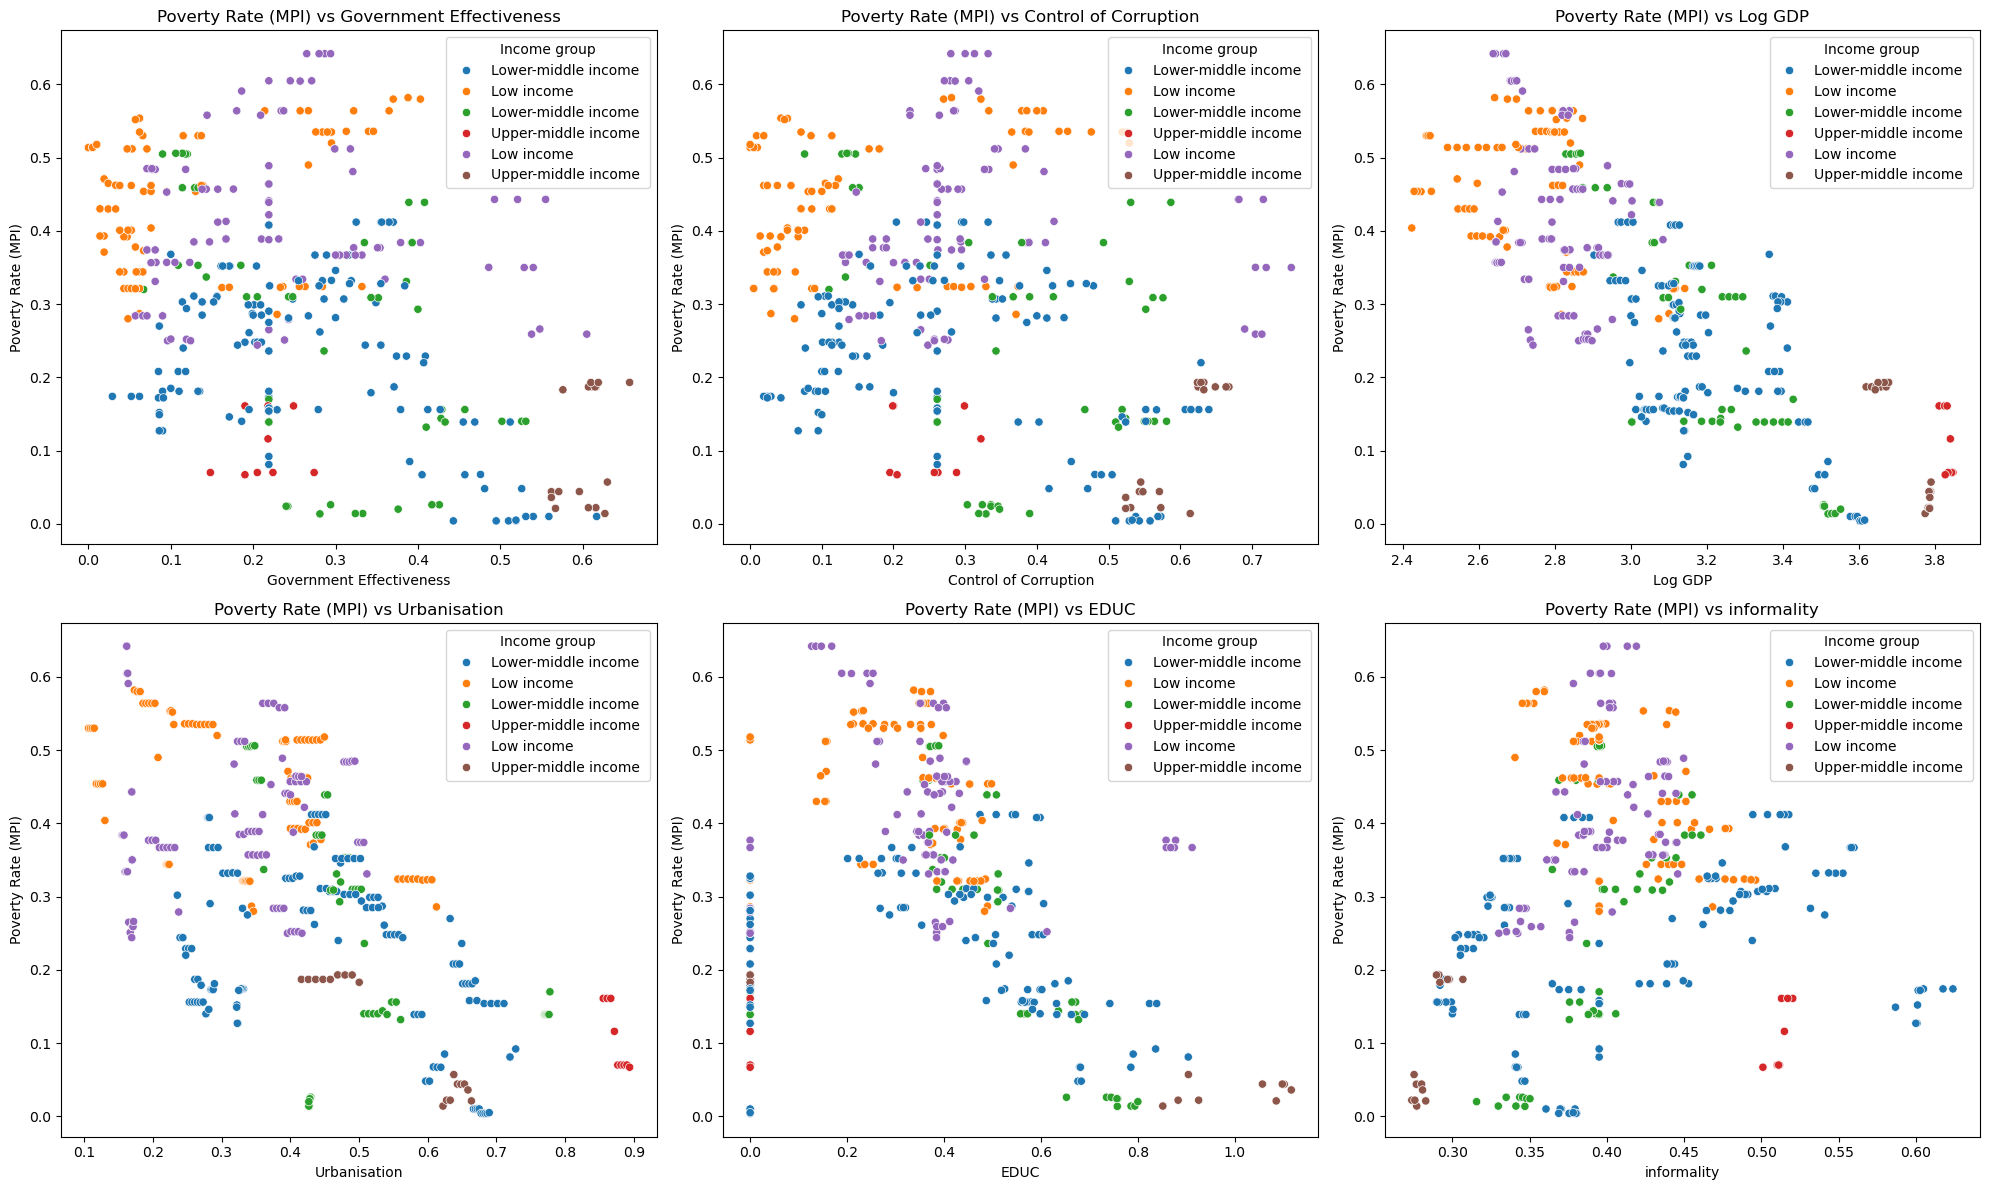

In [31]:
# Scatter plots for key relationships
print("\nKey Feature Relationships:")
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

features_to_plot = ['Government Effectiveness', 'Control of Corruption', 'Log GDP', 
                    'Urbanisation', 'EDUC', 'informality']

for i, feature in enumerate(features_to_plot):
    sns.scatterplot(x=df[feature], y=df['MPI'], hue=df['Income group'], ax=axes[i])
    axes[i].set_title(f'Poverty Rate (MPI) vs {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Poverty Rate (MPI)')
    
plt.tight_layout()
plt.show()

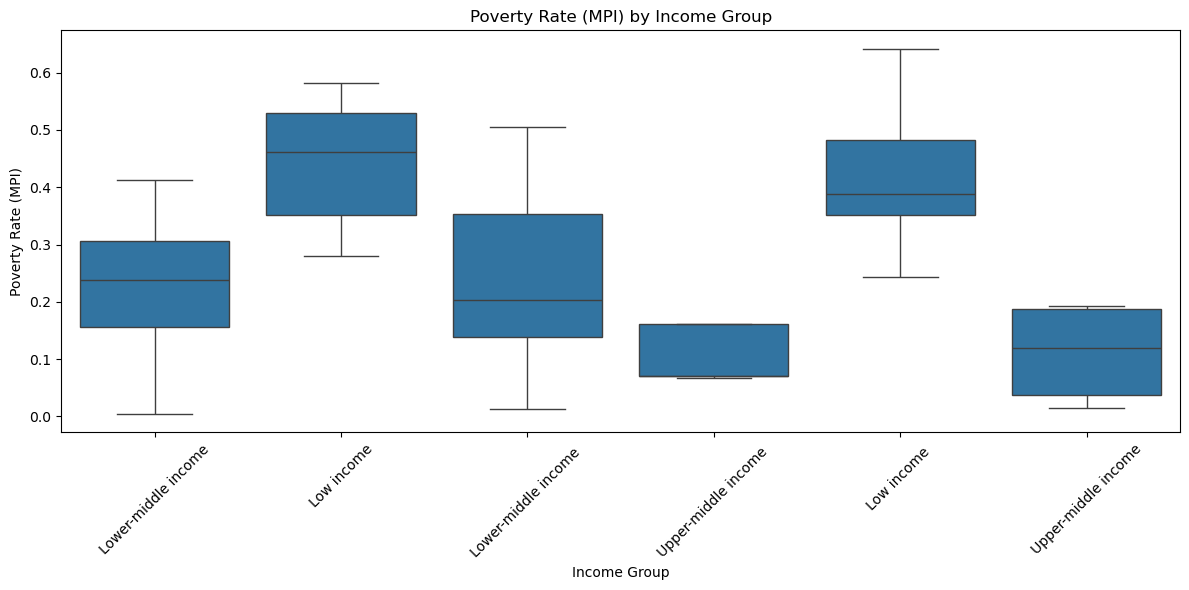

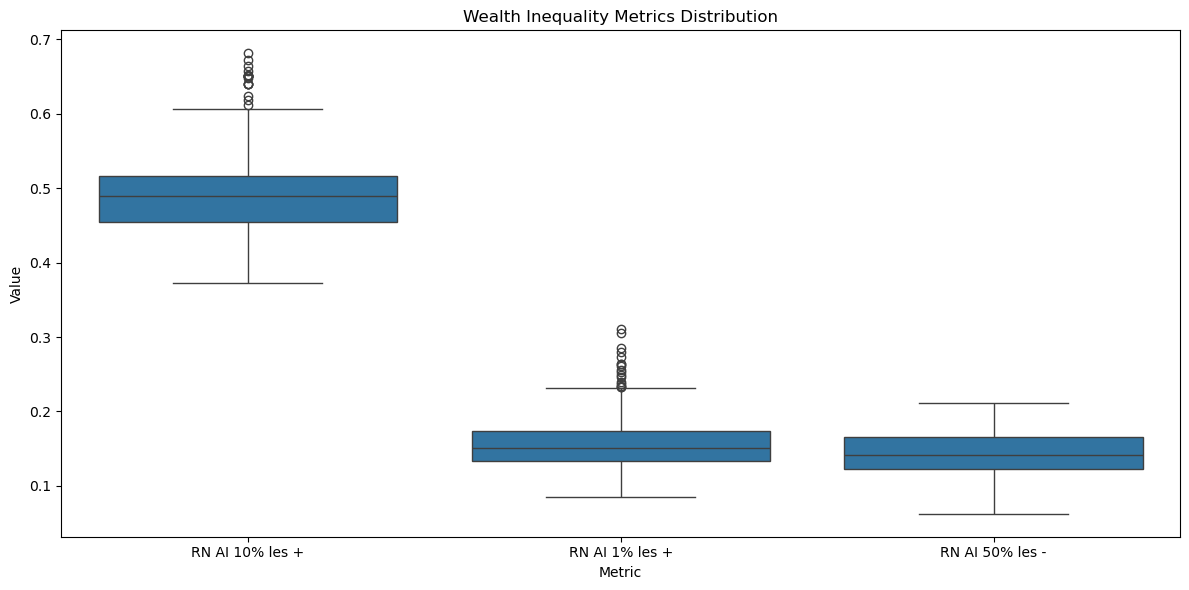

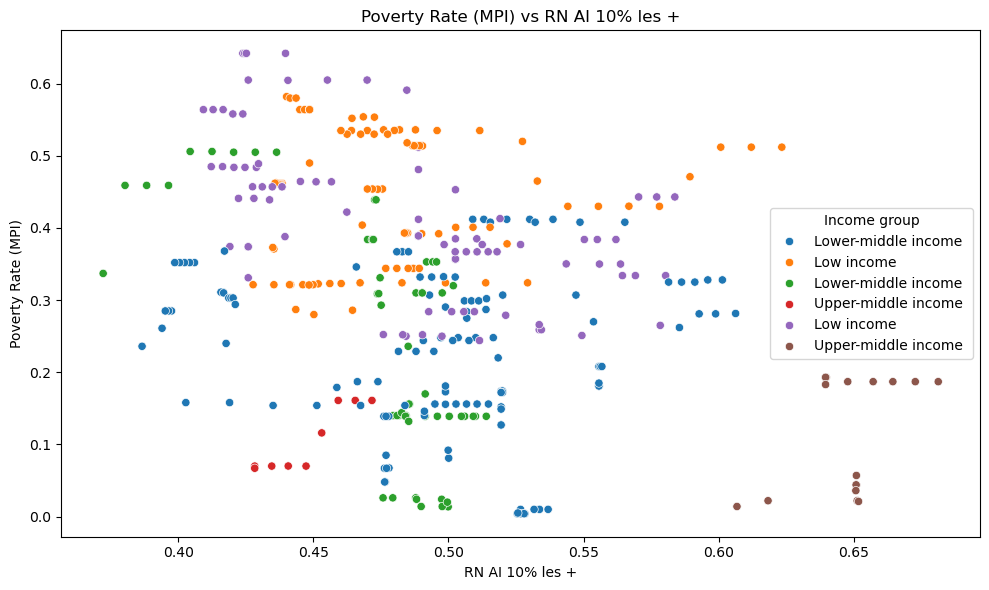

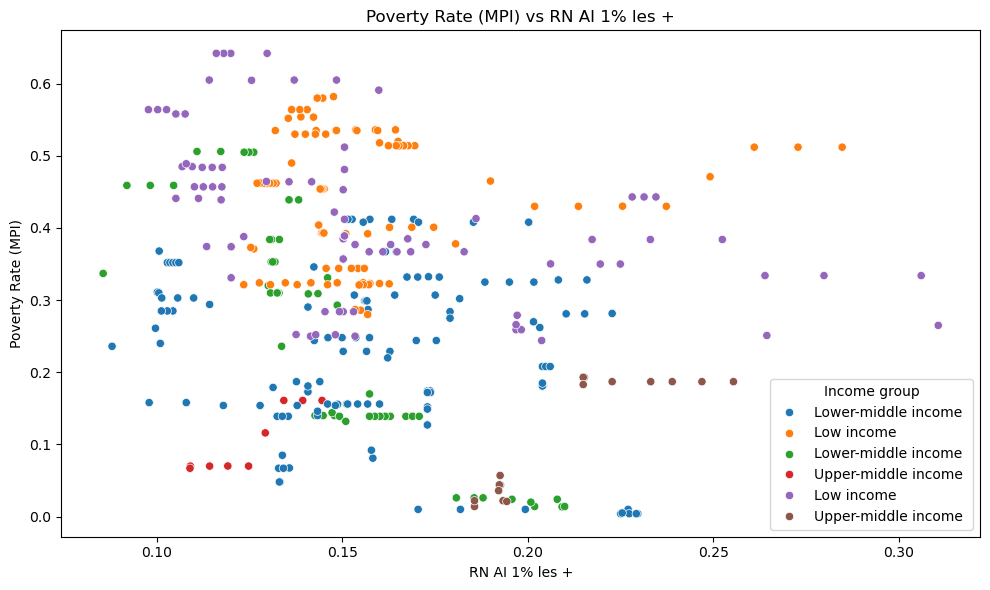

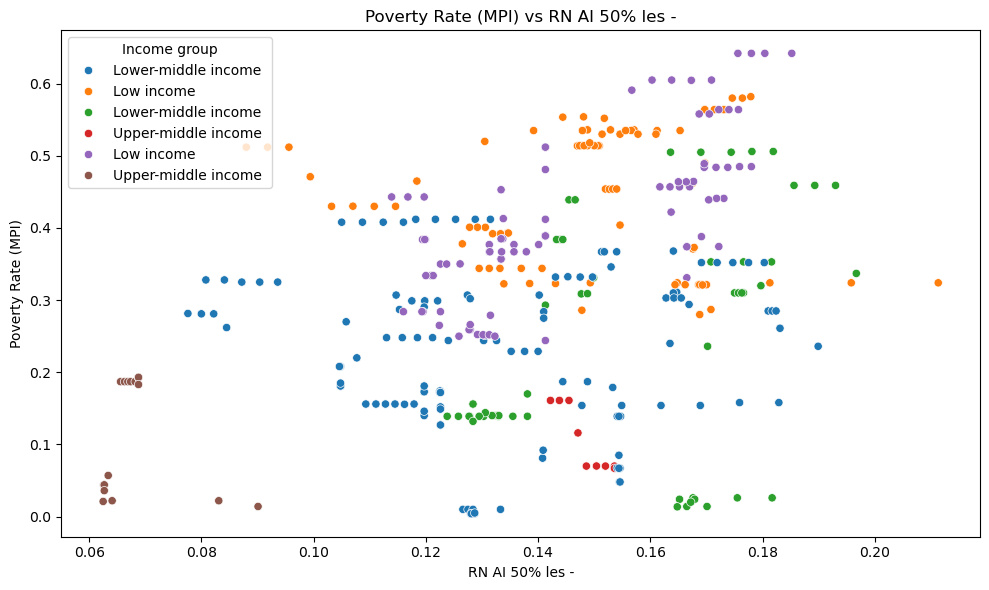

In [33]:

# Boxplot of Poverty Rate by Income Group
plt.figure(figsize=(12, 6))
sns.boxplot(x='Income group', y='MPI', data=df)
plt.title('Poverty Rate (MPI) by Income Group')
plt.xlabel('Income Group')
plt.ylabel('Poverty Rate (MPI)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Additional analysis - wealth inequality metrics
if all(col in df.columns for col in ['RN AI 10% les +', 'RN AI 1% les +', 'RN AI 50% les -']):
    plt.figure(figsize=(12, 6))
    
    # Create a melted dataframe for easier plotting
    inequality_data = df[['Countries', 'RN AI 10% les +', 'RN AI 1% les +', 'RN AI 50% les -']].melt(
        id_vars=['Countries'], 
        var_name='Inequality Metric', 
        value_name='Value'
    )
    
    sns.boxplot(x='Inequality Metric', y='Value', data=inequality_data)
    plt.title('Wealth Inequality Metrics Distribution')
    plt.xlabel('Metric')
    plt.ylabel('Value')
    plt.tight_layout()
    plt.show()
    
    # Correlation between inequality and poverty
    inequality_cols = ['RN AI 10% les +', 'RN AI 1% les +', 'RN AI 50% les -']
    for col in inequality_cols:
        plt.figure(figsize=(10, 6))
        sns.scatterplot(x=df[col], y=df['MPI'], hue=df['Income group'])
        plt.title(f'Poverty Rate (MPI) vs {col}')
        plt.xlabel(col)
        plt.ylabel('Poverty Rate (MPI)')
        plt.tight_layout()
        plt.show()

In [45]:
print("\n----- Model Building -----")
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
# Define features and target
X = df.drop(['MPI', 'i', 't', 'Countries', 'Années'], axis=1)  # Drop indices, identifiers and target
y = df['MPI']

# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()

# Create preprocessing pipeline for both numerical and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])



----- Model Building -----


In [51]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define models to evaluate
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

# Evaluate each model
results = {}
print("\nModel Evaluation:")
for name, model in models.items():
    # Create and evaluate the pipeline
    pipe = Pipeline(steps=[('preprocessor', preprocessor),
                           ('model', model)])
      # Cross-validation
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    mse_scores = -cv_scores
    rmse_scores = np.sqrt(mse_scores)
    
    # Fit on training data
    pipe.fit(X_train, y_train)
    
    # Predict on test data
    y_pred = pipe.predict(X_test)
    test_mse = mean_squared_error(y_test, y_pred)
    test_rmse = np.sqrt(test_mse)
    test_r2 = r2_score(y_test, y_pred)
    
    # Store results
    results[name] = {
        'CV RMSE': rmse_scores.mean(),
        'Test RMSE': test_rmse,
        'Test R²': test_r2
    }
    
    # Print results
    print(f"\n{name}:")
    print(f"  CV RMSE: {rmse_scores.mean():.4f}")
    print(f"  Test RMSE: {test_rmse:.4f}")
    print(f"  Test R²: {test_r2:.4f}")
    


Model Evaluation:

Linear Regression:
  CV RMSE: 0.0769
  Test RMSE: 0.0798
  Test R²: 0.7650

Ridge Regression:
  CV RMSE: 0.0768
  Test RMSE: 0.0795
  Test R²: 0.7667

Lasso Regression:
  CV RMSE: 0.1555
  Test RMSE: 0.1646
  Test R²: -0.0001

Random Forest:
  CV RMSE: 0.0454
  Test RMSE: 0.0413
  Test R²: 0.9370

Gradient Boosting:
  CV RMSE: 0.0434
  Test RMSE: 0.0422
  Test R²: 0.9344


In [53]:
# Compare models
results_df = pd.DataFrame(results).T
display(results_df)

# Select the best model (based on test R²)
best_model_name = results_df['Test R²'].idxmax()
print(f"\nBest performing model: {best_model_name}")

# Fit the best model on all training data
best_pipe = Pipeline(steps=[('preprocessor', preprocessor),
                           ('model', models[best_model_name])])
best_pipe.fit(X_train, y_train)

# If the best model is Random Forest or Gradient Boosting, we can look at feature importance
if best_model_name in ['Random Forest', 'Gradient Boosting']:
    # Get feature names after preprocessing
    cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
    feature_names = numerical_cols + cat_feature_names.tolist()
    
    # Get feature importances
    importances = best_pipe.named_steps['model'].feature_importances_
    
    # Sort features by importance
    indices = np.argsort(importances)[::-1]
    
    # Print feature ranking
    print("\nFeature importance ranking:")
    for i, idx in enumerate(indices[:10]):  # Show top 10 features
        if idx < len(feature_names):
            print(f"{i+1}. {feature_names[idx]} ({importances[idx]:.4f})")

,CV RMSE,Test RMSE,Test R²
Linear Regression,0.076915,0.079775,0.765018
Ridge Regression,0.076817,0.079497,0.766654
Lasso Regression,0.155453,0.164575,-0.000064
Random Forest,0.045352,0.041293,0.937041
Gradient Boosting,0.043360,0.042151,0.934400



Best performing model: Random Forest

Feature importance ranking:
1. Log GDP (0.6398)
2. Croiss Pop (0.0978)
3. RN AI 50% les - (0.0799)
4. informality (0.0565)
5. Urbanisation (0.0369)
6. Dev fin (0.0203)
7. EDUC (0.0172)
8. Control of Corruption (0.0154)
9. RN AI 1% les + (0.0113)
10. RN AI 10% les + (0.0094)


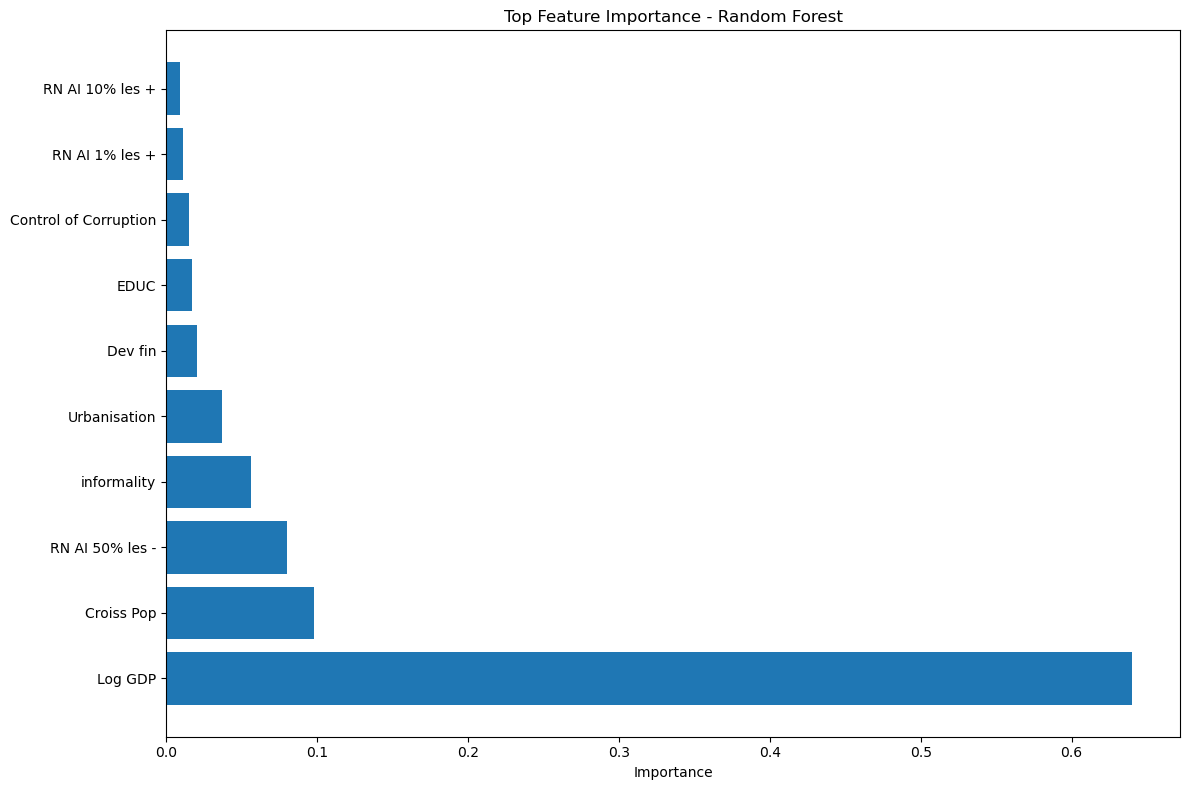

In [55]:
 # Plot feature importances
plt.figure(figsize=(12, 8))
top_indices = indices[:10]
top_features = [feature_names[i] for i in top_indices if i < len(feature_names)]
top_importances = importances[top_indices]
    
plt.barh(range(len(top_features)), top_importances, align='center')
plt.yticks(range(len(top_features)), top_features)
plt.xlabel('Importance')
plt.title(f'Top Feature Importance - {best_model_name}')
plt.tight_layout()
plt.show()


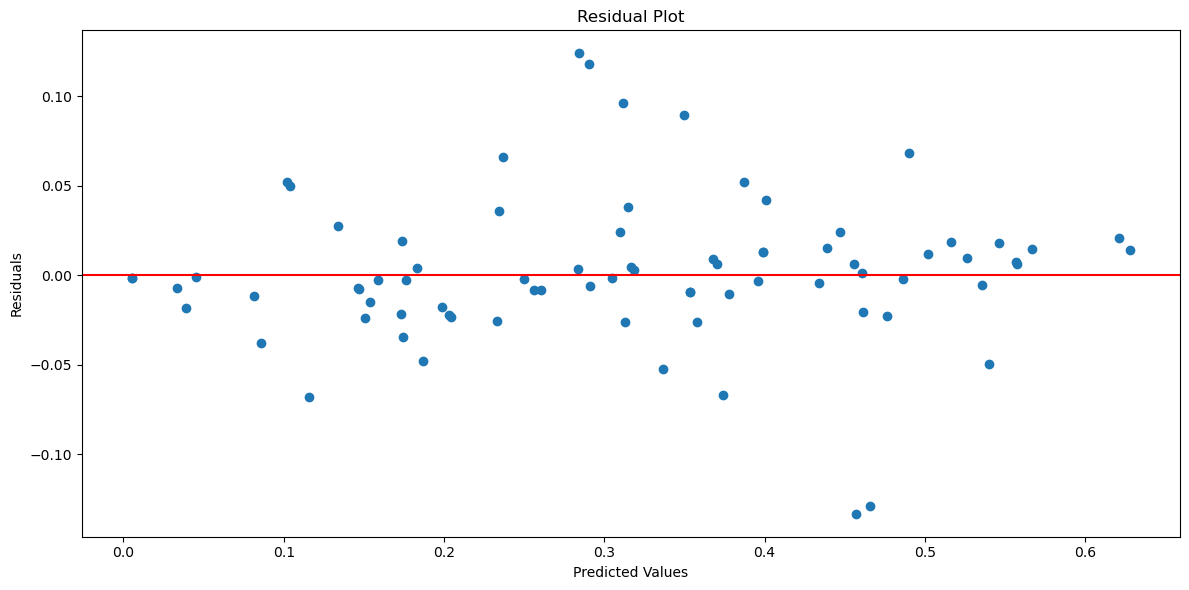

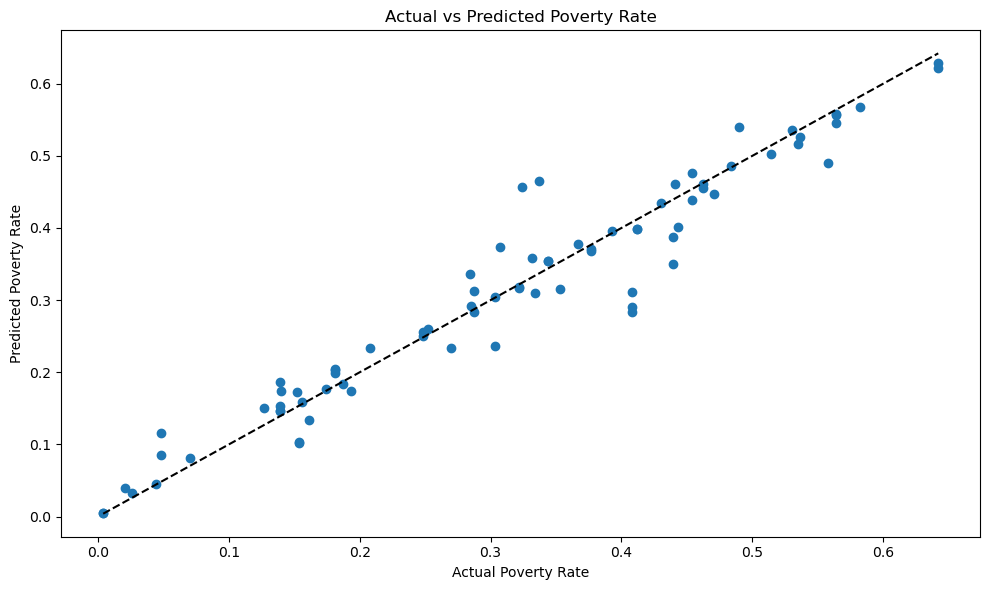

In [57]:
# Analyze residuals for the best model
y_pred = best_pipe.predict(X_test)
residuals = y_test - y_pred

plt.figure(figsize=(12, 6))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='-')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.xlabel('Actual Poverty Rate')
plt.ylabel('Predicted Poverty Rate')
plt.title('Actual vs Predicted Poverty Rate')
plt.tight_layout()
plt.show()

In [59]:



print("\nRecommended Features for Predicting Poverty Rate:")
if best_model_name in ['Random Forest', 'Gradient Boosting']:
    print("Based on the feature importance analysis, the most important features are:")
    for i, idx in enumerate(indices[:5]):  # Show top 5 features
        if idx < len(feature_names):
            print(f"- {feature_names[idx]}")
else:
    # For linear models, we can look at coefficients
    if best_model_name in ['Linear Regression', 'Ridge Regression', 'Lasso Regression']:
        model_coefs = best_pipe.named_steps['model'].coef_
        
        # Get feature names after preprocessing
        cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
        feature_names = numerical_cols + cat_feature_names.tolist()
        
        # Create a DataFrame of coefficients
        coef_df = pd.DataFrame({
            'Feature': feature_names[:len(model_coefs)],
            'Coefficient': model_coefs
        })
        
        # Sort by absolute coefficient value
        coef_df['Abs_Coef'] = coef_df['Coefficient'].abs()
        coef_df = coef_df.sort_values('Abs_Coef', ascending=False).head(5)
        
        print("Based on coefficient analysis, the most important features are:")
        for _, row in coef_df.iterrows():
            print(f"- {row['Feature']} (coefficient: {row['Coefficient']:.4f})")
    else:
        print("Based on correlation analysis, the features most correlated with Poverty Rate are:")
        for feature, corr in correlations.iloc[1:6].items():
            print(f"- {feature} (correlation: {corr:.4f})")


Recommended Features for Predicting Poverty Rate:
Based on the feature importance analysis, the most important features are:
- Log GDP
- Croiss Pop
- RN AI 50% les -
- informality
- Urbanisation
